In [1]:
!pipreqs test_classifiers.py

Traceback (most recent call last):
  File "/opt/conda/bin/pipreqs", line 8, in <module>
    sys.exit(main())
  File "/opt/conda/lib/python3.8/site-packages/pipreqs/pipreqs.py", line 488, in main
    init(args)
  File "/opt/conda/lib/python3.8/site-packages/pipreqs/pipreqs.py", line 478, in init
    generate_requirements_file(path, imports, symbol)
  File "/opt/conda/lib/python3.8/site-packages/pipreqs/pipreqs.py", line 157, in generate_requirements_file
    with _open(path, "w") as out_file:
  File "/opt/conda/lib/python3.8/contextlib.py", line 113, in __enter__
    return next(self.gen)
  File "/opt/conda/lib/python3.8/site-packages/pipreqs/pipreqs.py", line 81, in _open
    file = open(filename, mode)
NotADirectoryError: [Errno 20] Not a directory: 'test_classifiers.py/requirements.txt'


In [1]:
root = '/path/to/npy/files/root'
test_csv = '/path/to/filename/and/labels/csv'

#name of the column in test_csv where the boolean label for CKD (True)/No CKD (False) is stored
target='label'

In [2]:
import numpy as np
from paths import FilePaths
from tuningfunctions import get_data_loaders, get_criterion, Objective, run_trials
import models
import torch
import pandas as pd
import matplotlib.pyplot as plt
from ECG import EchoECG
from tqdm import tqdm
import sklearn

In [3]:
root = '/workspace/data/drives/Local_SSD/sdd/data/Remade with New Coefficents'
test_csv = '/workspace/data/drives/Local_SSD/sdc/kidney_disease/DefinitiveAllStagesData/under_60_years_old_subset_test.csv'
target='label'

def test_model(one_lead=False):
    torch.cuda.empty_cache()

    if(one_lead):
        model = models.EffNet(channels = [32,16,24,40,80,112,192,320,1280,1],dilation = 2,
                                  stride = 8,
                                  reg = False, 
                                  start_channels=1)
        model.load_state_dict(torch.load('one_lead_weights.pt'))
    else:
        model = models.EffNet(channels = [32,16,24,40,80,112,192,320,1280,1],dilation = 2,
                                  stride = 8,
                                  reg = False, 
                                  start_channels=12)
        model.load_state_dict(torch.load('twelve_lead_weights.pt'))
    model.eval()

    test_ds = EchoECG(root=root,
                      csv=test_csv,
                      model='RCRI_Net', 
                      rolling=0, 
                      downsample=1,
                      target=target, 
                      one_lead=one_lead,
                      return_filename=False)
    
    test_dataloader = torch.utils.data.DataLoader(test_ds,
                                                batch_size=2000, 
                                                num_workers=8, #Feel free to increase this depending 
                                                               #on your machine's specs to speed up inference
                                                drop_last=False)

    all_labels = []
    all_preds = []
    with torch.no_grad():
        for ecg, labels in tqdm(test_dataloader):

            all_preds += list(model(ecg))
            all_labels += list(labels)
            
    return all_labels, all_preds


depth  [1, 2, 2, 3, 3, 3, 3]


  0%|          | 0/5 [00:00<?, ?it/s]

missing 0.0
Index(['Unnamed: 0', 'Unnamed: 0.1', 'Filename', 'MRN', 'EKG_date', 'Gender',
       'PatientAge', 'primary', 'label'],
      dtype='object')


100%|██████████| 5/5 [00:13<00:00,  2.73s/it]


One-Lead Model
0.8230833435550062


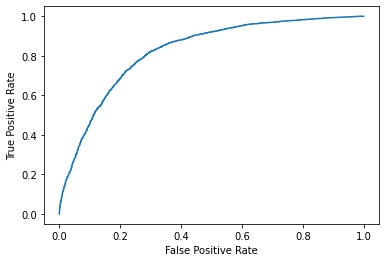

In [4]:
one_labels, one_preds = test_model(one_lead=True)
fpr, tpr, thresholds = sklearn.metrics.roc_curve(one_labels, one_preds)
sklearn.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
print('One-Lead Model')
print(sklearn.metrics.auc(fpr, tpr))

depth  [1, 2, 2, 3, 3, 3, 3]


  0%|          | 0/5 [00:00<?, ?it/s]

missing 0.0
Index(['Unnamed: 0', 'Unnamed: 0.1', 'Filename', 'MRN', 'EKG_date', 'Gender',
       'PatientAge', 'primary', 'label'],
      dtype='object')


100%|██████████| 5/5 [00:14<00:00,  2.84s/it]


Twelve-Lead Model
0.8394663932488704


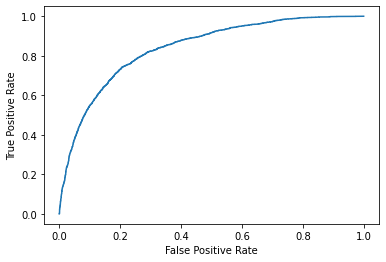

In [5]:
twelve_labels, twelve_preds = test_model(one_lead=False)
fpr, tpr, thresholds = sklearn.metrics.roc_curve(twelve_labels, twelve_preds)
sklearn.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
print('Twelve-Lead Model')
print(sklearn.metrics.auc(fpr, tpr))

In [6]:
!pip install pipreqs